In [12]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# =====================================================
# GLOBAL CONFIG
# =====================================================

RANDOM_STATE = 42

TEST_SIZE = 0.2

TOP_MRI_FEATURES = 30

MODALITY_DROPOUT_RATE = 0.3

np.random.seed(RANDOM_STATE)

In [13]:
# =====================================================
# LOAD CLINICAL DATA
# =====================================================

clinical_full = pd.read_csv("ADSL.csv")

clinical_full = clinical_full[
    clinical_full["DX"].isin(["CN", "DEM"])
].copy()

clinical_full["LABEL"] = clinical_full["DX"].map({
    "CN": 0,
    "DEM": 1
})

# =====================================================
# BUILD CLINICAL DATASET
# =====================================================

clinical = clinical_full[[
    "SUBJID",
    "AGE",
    "SEX",
    "EDUC",
    "RAVLTFG",
    "RAVLTIMM",
    "TRABSCOR",
    "LABEL"
]].copy()

clinical = clinical.rename(columns={
    "SUBJID": "RID"
})

clinical["SEX"] = clinical["SEX"].map({
    "Male": 0,
    "Female": 1
})

clinical = clinical.dropna()

clinical = clinical.drop_duplicates(
    subset="RID"
)

# =====================================================
# LOAD MRI DATA
# =====================================================

mri = pd.read_csv("UCSFFSX6.csv")

mri["EXAMDATE"] = pd.to_datetime(
    mri["EXAMDATE"]
)

mri = mri.sort_values("EXAMDATE")

mri = mri.drop_duplicates(
    subset="RID",
    keep="last"
)

# =====================================================
# MRI FEATURE FILTERING
# =====================================================

numeric_cols = mri.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

mri_features = [
    c for c in numeric_cols
    if c not in ["RID", "IMAGEUID"]
]

missing_pct = mri[mri_features].isnull().mean()

good_features = missing_pct[
    missing_pct < 0.3
].index.tolist()
mri = mri[["RID"] + good_features]

# =====================================================
# MERGE DATASETS
# =====================================================

merged = pd.merge(
    clinical,
    mri,
    on="RID",
    how="inner"
)

# =====================================================
# IMPUTATION
# =====================================================

feature_cols = [
    c for c in merged.columns
    if c not in ["RID", "LABEL"]
]

imputer = SimpleImputer(
    strategy="median"
)

merged[feature_cols] = imputer.fit_transform(
    merged[feature_cols]
)

# =====================================================
# TOP MRI FEATURES
# =====================================================

mri_features = [
    c for c in merged.columns
    if c.startswith("ST")
]

mri_variance = merged[mri_features].var()

top_mri_features = (
    mri_variance
    .sort_values(ascending=False)
    .head(TOP_MRI_FEATURES)
    .index
    .tolist()
)

# =====================================================
# FINAL FEATURES
# =====================================================

clinical_features = [
    "AGE",
    "SEX",
    "EDUC",
    "RAVLTFG",
    "RAVLTIMM",
    "TRABSCOR"
]

final_features = (
    clinical_features
    + top_mri_features
)

X = merged[final_features]

y = merged["LABEL"]

print("Merged shape:", merged.shape)
print(y.value_counts())

Merged shape: (626, 331)
LABEL
0    561
1     65
Name: count, dtype: int64


In [14]:
# =====================================================
# TRAIN / TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# =====================================================
# SCALE
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =====================================================
# MODELS
# =====================================================

models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(
        X_test_scaled
    )[:,1]

    auc = roc_auc_score(
        y_test,
        probs
    )

    results.append({
        "Model": name,
        "AUC": auc
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="AUC",
    ascending=False
)

print(results_df)

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

                 Model       AUC
2          Extra Trees  0.973792
1        Random Forest  0.963240
0  Logistic Regression  0.926481


In [15]:
# =====================================================
# MISSING CLINICAL MODALITY
# =====================================================

X_test_missing = X_test.copy()

X_test_missing[
    clinical_features
] = 0

X_test_missing_scaled = scaler.transform(
    X_test_missing
)

missing_probs = best_model.predict_proba(
    X_test_missing_scaled
)[:,1]

missing_auc = roc_auc_score(
    y_test,
    missing_probs
)

print("Baseline AUC:")
print(results_df.iloc[0]["AUC"])

print("\nMissing Clinical AUC:")
print(missing_auc)

print("\nPerformance Drop:")
print(
    results_df.iloc[0]["AUC"] - missing_auc
)

Baseline AUC:
0.9737916950306331

Missing Clinical AUC:
0.7256637168141593

Performance Drop:
0.2481279782164738


In [16]:
# =====================================================
# MODALITY DROPOUT TRAINING
# =====================================================

X_train_robust = X_train.copy()

mask = np.random.rand(
    len(X_train_robust)
) < MODALITY_DROPOUT_RATE

X_train_robust.loc[
    mask,
    clinical_features
] = 0

robust_scaler = StandardScaler()

X_train_robust_scaled = robust_scaler.fit_transform(
    X_train_robust
)

X_test_scaled_robust = robust_scaler.transform(
    X_test
)

X_test_missing_scaled_robust = robust_scaler.transform(
    X_test_missing
)

robust_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

robust_model.fit(
    X_train_robust_scaled,
    y_train
)

# =====================================================
# EVALUATION
# =====================================================

robust_full_probs = robust_model.predict_proba(
    X_test_scaled_robust
)[:,1]

robust_missing_probs = robust_model.predict_proba(
    X_test_missing_scaled_robust
)[:,1]

robust_full_auc = roc_auc_score(
    y_test,
    robust_full_probs
)

robust_missing_auc = roc_auc_score(
    y_test,
    robust_missing_probs
)

print("Robust Full AUC:")
print(robust_full_auc)

print("\nRobust Missing AUC:")
print(robust_missing_auc)

Robust Full AUC:
0.9414567733151804

Robust Missing AUC:
0.7086453369639211



===== FOLD 1 =====

===== FOLD 2 =====

===== FOLD 3 =====

===== FOLD 4 =====

===== FOLD 5 =====

FINAL CROSS-VALIDATED RESULTS TABLE
      Model  Mean Full AUC Mean Missing AUC Mean Performance Drop
0  Baseline  0.963 ± 0.025    0.734 ± 0.056         0.230 ± 0.060
1    Robust  0.959 ± 0.017    0.780 ± 0.044         0.179 ± 0.043


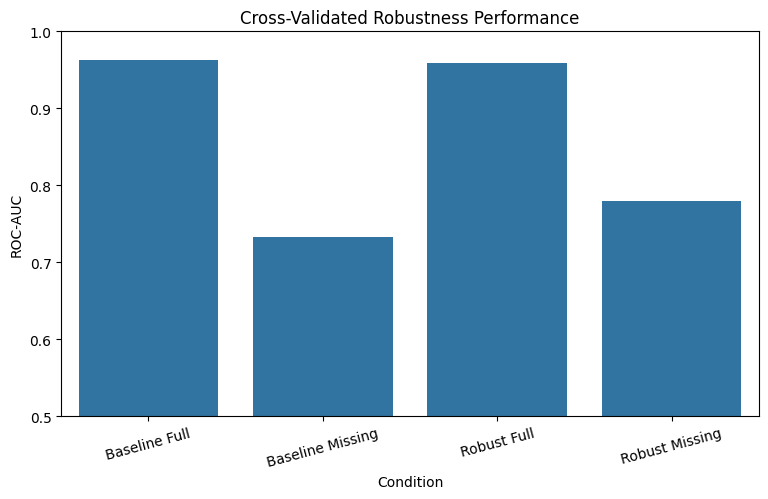

In [17]:
# =====================================================
# CELL 6 — CROSS-VALIDATED ROBUSTNESS EVALUATION
# =====================================================
import os

os.makedirs("results", exist_ok=True)

os.makedirs("figures", exist_ok=True)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# =====================================================
# STRATIFIED 5-FOLD CV
# =====================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# =====================================================
# STORE RESULTS
# =====================================================

baseline_full_aucs = []

baseline_missing_aucs = []

robust_full_aucs = []

robust_missing_aucs = []

# =====================================================
# CROSS-VALIDATION LOOP
# =====================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y)
):

    print(f"\n===== FOLD {fold+1} =====")

    # -----------------------------------------
    # SPLIT
    # -----------------------------------------

    X_train_cv = X.iloc[train_idx].copy()

    X_test_cv = X.iloc[test_idx].copy()

    y_train_cv = y.iloc[train_idx]

    y_test_cv = y.iloc[test_idx]

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    scaler_baseline = StandardScaler()

    X_train_scaled = scaler_baseline.fit_transform(
        X_train_cv
    )

    X_test_scaled = scaler_baseline.transform(
        X_test_cv
    )

    baseline_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    baseline_model.fit(
        X_train_scaled,
        y_train_cv
    )

    # -----------------------------------------
    # BASELINE FULL PERFORMANCE
    # -----------------------------------------

    baseline_probs = baseline_model.predict_proba(
        X_test_scaled
    )[:,1]

    baseline_auc = roc_auc_score(
        y_test_cv,
        baseline_probs
    )

    baseline_full_aucs.append(
        baseline_auc
    )

    # -----------------------------------------
    # BASELINE MISSING MODALITY
    # -----------------------------------------

    X_test_missing = X_test_cv.copy()

    X_test_missing[
        clinical_features
    ] = 0

    X_test_missing_scaled = scaler_baseline.transform(
        X_test_missing
    )

    baseline_missing_probs = baseline_model.predict_proba(
        X_test_missing_scaled
    )[:,1]

    baseline_missing_auc = roc_auc_score(
        y_test_cv,
        baseline_missing_probs
    )

    baseline_missing_aucs.append(
        baseline_missing_auc
    )

    # =====================================================
    # ROBUST MODEL
    # =====================================================

    X_train_robust = X_train_cv.copy()

    mask = np.random.rand(
        len(X_train_robust)
    ) < MODALITY_DROPOUT_RATE

    X_train_robust.loc[
        mask,
        clinical_features
    ] = 0

    scaler_robust = StandardScaler()

    X_train_robust_scaled = scaler_robust.fit_transform(
        X_train_robust
    )

    X_test_scaled_robust = scaler_robust.transform(
        X_test_cv
    )

    X_test_missing_scaled_robust = scaler_robust.transform(
        X_test_missing
    )

    robust_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    robust_model.fit(
        X_train_robust_scaled,
        y_train_cv
    )

    # -----------------------------------------
    # ROBUST FULL PERFORMANCE
    # -----------------------------------------

    robust_full_probs = robust_model.predict_proba(
        X_test_scaled_robust
    )[:,1]

    robust_full_auc = roc_auc_score(
        y_test_cv,
        robust_full_probs
    )

    robust_full_aucs.append(
        robust_full_auc
    )

    # -----------------------------------------
    # ROBUST MISSING PERFORMANCE
    # -----------------------------------------

    robust_missing_probs = robust_model.predict_proba(
        X_test_missing_scaled_robust
    )[:,1]

    robust_missing_auc = roc_auc_score(
        y_test_cv,
        robust_missing_probs
    )

    robust_missing_aucs.append(
        robust_missing_auc
    )

# =====================================================
# SUMMARY STATISTICS
# =====================================================

baseline_drops = [

    full - missing

    for full, missing in zip(
        baseline_full_aucs,
        baseline_missing_aucs
    )
]

robust_drops = [

    full - missing

    for full, missing in zip(
        robust_full_aucs,
        robust_missing_aucs
    )
]

# =====================================================
# FINAL PAPER TABLE
# =====================================================

paper_results = pd.DataFrame({

    "Model": [
        "Baseline",
        "Robust"
    ],

    "Mean Full AUC": [

        f"{np.mean(baseline_full_aucs):.3f} ± {np.std(baseline_full_aucs):.3f}",

        f"{np.mean(robust_full_aucs):.3f} ± {np.std(robust_full_aucs):.3f}"
    ],

    "Mean Missing AUC": [

        f"{np.mean(baseline_missing_aucs):.3f} ± {np.std(baseline_missing_aucs):.3f}",

        f"{np.mean(robust_missing_aucs):.3f} ± {np.std(robust_missing_aucs):.3f}"
    ],

    "Mean Performance Drop": [

        f"{np.mean(baseline_drops):.3f} ± {np.std(baseline_drops):.3f}",

        f"{np.mean(robust_drops):.3f} ± {np.std(robust_drops):.3f}"
    ]
})

# =====================================================
# DISPLAY RESULTS
# =====================================================

print("\n========================================")
print("FINAL CROSS-VALIDATED RESULTS TABLE")
print("========================================")

print(paper_results)

# =====================================================
# SAVE RESULTS
# =====================================================

paper_results.to_csv(
    "results/final_results_table.csv",
    index=False
)

# =====================================================
# VISUALIZATION
# =====================================================

plot_df = pd.DataFrame({

    "Condition": [

        "Baseline Full",
        "Baseline Missing",
        "Robust Full",
        "Robust Missing"
    ],

    "Mean AUC": [

        np.mean(baseline_full_aucs),

        np.mean(baseline_missing_aucs),

        np.mean(robust_full_aucs),

        np.mean(robust_missing_aucs)
    ]
})

plt.figure(figsize=(9,5))

sns.barplot(
    data=plot_df,
    x="Condition",
    y="Mean AUC"
)

plt.ylim(0.5, 1.0)

plt.title(
    "Cross-Validated Robustness Performance"
)

plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.savefig(
    "figures/cv_robustness_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


MISSINGNESS EXPERIMENTS

------------------------------------
MISSINGNESS LEVEL: 10%
------------------------------------
Baseline AUC: 0.8890401633764464
Robust AUC: 0.9033356024506467

------------------------------------
MISSINGNESS LEVEL: 30%
------------------------------------
Baseline AUC: 0.8413886997957795
Robust AUC: 0.8938053097345133

------------------------------------
MISSINGNESS LEVEL: 50%
------------------------------------
Baseline AUC: 0.8012253233492171
Robust AUC: 0.9162695711368278

------------------------------------
MISSINGNESS LEVEL: 70%
------------------------------------
Baseline AUC: 0.7140912185159974
Robust AUC: 0.7685500340367597

MISSINGNESS RESULTS
   Missingness (%)  Baseline AUC  Robust AUC
0               10      0.889040    0.903336
1               30      0.841389    0.893805
2               50      0.801225    0.916270
3               70      0.714091    0.768550


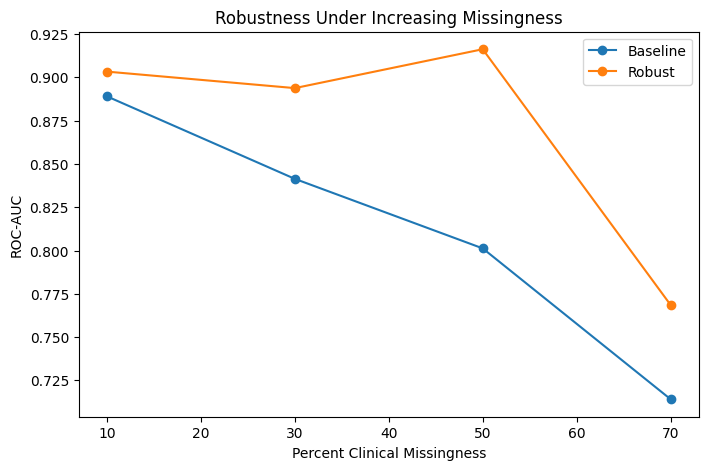


ABLATION STUDY

------------------------------------
DROPOUT LEVEL: 0%
------------------------------------
Full AUC: 0.9264805990469708
Missing AUC: 0.6371681415929203
Performance Drop: 0.28931245745405043

------------------------------------
DROPOUT LEVEL: 10%
------------------------------------
Full AUC: 0.9380530973451328
Missing AUC: 0.6997957794417972
Performance Drop: 0.2382573179033356

------------------------------------
DROPOUT LEVEL: 30%
------------------------------------
Full AUC: 0.9441797140912186
Missing AUC: 0.7324710687542546
Performance Drop: 0.21170864533696399

------------------------------------
DROPOUT LEVEL: 50%
------------------------------------
Full AUC: 0.9469026548672566
Missing AUC: 0.7794417971409122
Performance Drop: 0.16746085772634434

ABLATION RESULTS
   Dropout Rate (%)  Full AUC  Missing AUC  Performance Drop
0                 0  0.926481     0.637168          0.289312
1                10  0.938053     0.699796          0.238257
2            

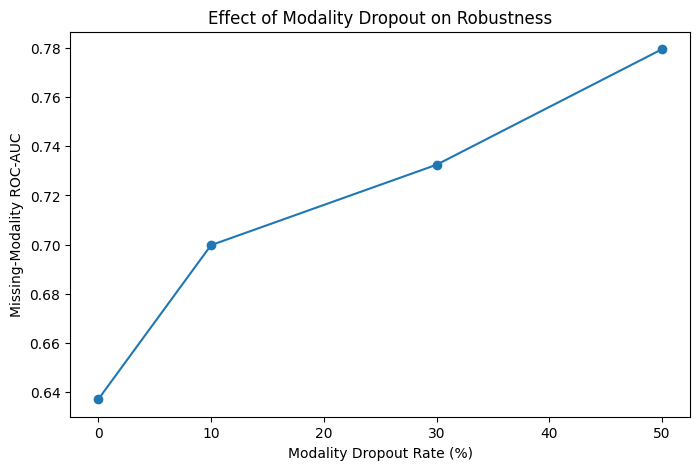

In [18]:
# =====================================================
# CELL 7 — MISSINGNESS + ABLATION EXPERIMENTS
# =====================================================
#
# This evaluates:
#
# 1. Increasing clinical missingness
# 2. Baseline vs Robust models
# 3. Different modality dropout strengths
#
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# =====================================================
# MISSINGNESS LEVELS
# =====================================================

missingness_levels = [
    0.1,
    0.3,
    0.5,
    0.7
]

# =====================================================
# DROPOUT LEVELS
# =====================================================

dropout_levels = [
    0.0,
    0.1,
    0.3,
    0.5
]

# =====================================================
# STORE RESULTS
# =====================================================

missingness_results = []

ablation_results = []

# =====================================================
# PART 1 — MISSINGNESS EXPERIMENT
# =====================================================

print("\n====================================")
print("MISSINGNESS EXPERIMENTS")
print("====================================")

for missing_rate in missingness_levels:

    print("\n------------------------------------")
    print(f"MISSINGNESS LEVEL: {int(missing_rate*100)}%")
    print("------------------------------------")

    # -----------------------------------------
    # CREATE FRESH MISSING TEST SET
    # -----------------------------------------

    X_test_missing_partial = X_test.copy()

    mask = np.random.rand(
        len(X_test_missing_partial)
    ) < missing_rate

    X_test_missing_partial.loc[
        mask,
        clinical_features
    ] = 0

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    baseline_scaler = StandardScaler()

    X_train_scaled = baseline_scaler.fit_transform(
        X_train
    )

    X_test_missing_scaled = baseline_scaler.transform(
        X_test_missing_partial
    )

    baseline_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    baseline_model.fit(
        X_train_scaled,
        y_train
    )

    baseline_probs = baseline_model.predict_proba(
        X_test_missing_scaled
    )[:,1]

    baseline_auc = roc_auc_score(
        y_test,
        baseline_probs
    )

    # =====================================================
    # ROBUST MODEL
    # =====================================================

    X_train_robust = X_train.copy()

    robust_mask = np.random.rand(
        len(X_train_robust)
    ) < MODALITY_DROPOUT_RATE

    X_train_robust.loc[
        robust_mask,
        clinical_features
    ] = 0

    robust_scaler = StandardScaler()

    X_train_robust_scaled = robust_scaler.fit_transform(
        X_train_robust
    )

    X_test_missing_scaled_robust = robust_scaler.transform(
        X_test_missing_partial
    )

    robust_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    robust_model.fit(
        X_train_robust_scaled,
        y_train
    )

    robust_probs = robust_model.predict_proba(
        X_test_missing_scaled_robust
    )[:,1]

    robust_auc = roc_auc_score(
        y_test,
        robust_probs
    )

    # -----------------------------------------
    # STORE RESULTS
    # -----------------------------------------

    missingness_results.append({

        "Missingness (%)": int(missing_rate * 100),

        "Baseline AUC": baseline_auc,

        "Robust AUC": robust_auc
    })

    print("Baseline AUC:", baseline_auc)

    print("Robust AUC:", robust_auc)

# =====================================================
# RESULTS DATAFRAME
# =====================================================

missingness_df = pd.DataFrame(
    missingness_results
)

print("\n====================================")
print("MISSINGNESS RESULTS")
print("====================================")

print(missingness_df)

# =====================================================
# SAVE RESULTS
# =====================================================

missingness_df.to_csv(
    "results/missingness_results.csv",
    index=False
)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    missingness_df["Missingness (%)"],
    missingness_df["Baseline AUC"],
    marker="o",
    label="Baseline"
)

plt.plot(
    missingness_df["Missingness (%)"],
    missingness_df["Robust AUC"],
    marker="o",
    label="Robust"
)

plt.xlabel(
    "Percent Clinical Missingness"
)

plt.ylabel("ROC-AUC")

plt.title(
    "Robustness Under Increasing Missingness"
)

plt.legend()

plt.savefig(
    "figures/missingness_experiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# PART 2 — MODALITY DROPOUT ABLATION STUDY
# =====================================================

print("\n====================================")
print("ABLATION STUDY")
print("====================================")

for dropout_rate in dropout_levels:

    print("\n------------------------------------")
    print(f"DROPOUT LEVEL: {int(dropout_rate*100)}%")
    print("------------------------------------")

    # -----------------------------------------
    # COPY TRAIN DATA
    # -----------------------------------------

    X_train_ablation = X_train.copy()

    # -----------------------------------------
    # APPLY MODALITY DROPOUT
    # -----------------------------------------

    if dropout_rate > 0:

        mask = np.random.rand(
            len(X_train_ablation)
        ) < dropout_rate

        X_train_ablation.loc[
            mask,
            clinical_features
        ] = 0

    # -----------------------------------------
    # SCALE
    # -----------------------------------------

    scaler_ablation = StandardScaler()

    X_train_ablation_scaled = scaler_ablation.fit_transform(
        X_train_ablation
    )

    # -----------------------------------------
    # CREATE FULL TEST DATA
    # -----------------------------------------

    X_test_scaled_ablation = scaler_ablation.transform(
        X_test
    )

    # -----------------------------------------
    # CREATE MISSING TEST DATA
    # -----------------------------------------

    X_test_missing_ablation = X_test.copy()

    X_test_missing_ablation[
        clinical_features
    ] = 0

    X_test_missing_scaled_ablation = scaler_ablation.transform(
        X_test_missing_ablation
    )

    # -----------------------------------------
    # TRAIN MODEL
    # -----------------------------------------

    ablation_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    ablation_model.fit(
        X_train_ablation_scaled,
        y_train
    )

    # -----------------------------------------
    # FULL PERFORMANCE
    # -----------------------------------------

    full_probs = ablation_model.predict_proba(
        X_test_scaled_ablation
    )[:,1]

    full_auc = roc_auc_score(
        y_test,
        full_probs
    )

    # -----------------------------------------
    # MISSING PERFORMANCE
    # -----------------------------------------

    missing_probs = ablation_model.predict_proba(
        X_test_missing_scaled_ablation
    )[:,1]

    missing_auc = roc_auc_score(
        y_test,
        missing_probs
    )

    performance_drop = (
        full_auc - missing_auc
    )

    # -----------------------------------------
    # STORE RESULTS
    # -----------------------------------------

    ablation_results.append({

        "Dropout Rate (%)": int(dropout_rate * 100),

        "Full AUC": full_auc,

        "Missing AUC": missing_auc,

        "Performance Drop": performance_drop
    })

    print("Full AUC:", full_auc)

    print("Missing AUC:", missing_auc)

    print("Performance Drop:", performance_drop)

# =====================================================
# RESULTS DATAFRAME
# =====================================================

ablation_df = pd.DataFrame(
    ablation_results
)

print("\n====================================")
print("ABLATION RESULTS")
print("====================================")

print(ablation_df)

# =====================================================
# SAVE RESULTS
# =====================================================

ablation_df.to_csv(
    "results/ablation_results.csv",
    index=False
)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    ablation_df["Dropout Rate (%)"],
    ablation_df["Missing AUC"],
    marker="o"
)

plt.xlabel(
    "Modality Dropout Rate (%)"
)

plt.ylabel(
    "Missing-Modality ROC-AUC"
)

plt.title(
    "Effect of Modality Dropout on Robustness"
)

plt.savefig(
    "figures/ablation_study.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


HEALTHCARE EVALUATION METRICS
Accuracy:     0.952
Precision:    0.733
Recall:       0.846
F1-Score:     0.786
Sensitivity:  0.846
Specificity:  0.965
ROC-AUC:      0.926

METRICS TABLE
        Metric     Value
0     Accuracy  0.952381
1    Precision  0.733333
2       Recall  0.846154
3     F1-Score  0.785714
4  Sensitivity  0.846154
5  Specificity  0.964602
6      ROC-AUC  0.926481


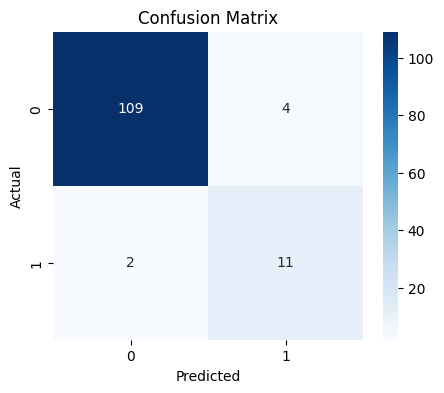

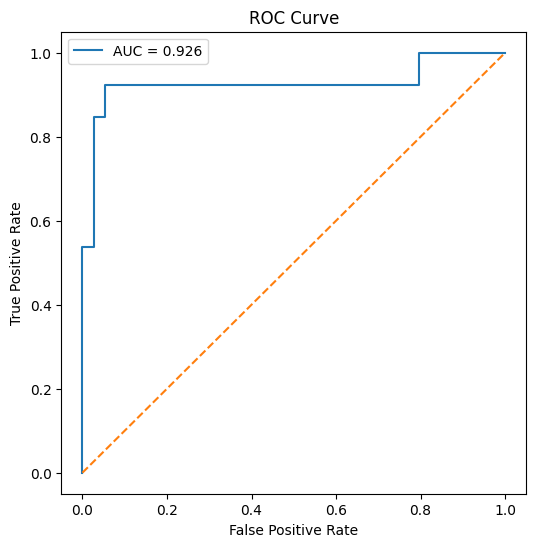

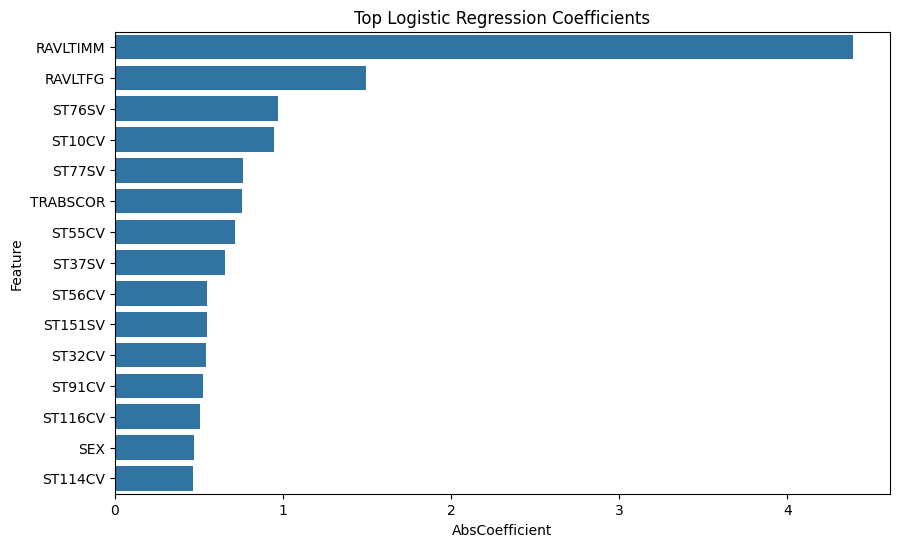


CONFUSION MATRIX INTERPRETATION
True Negatives (CN correctly identified): 109
False Positives (CN predicted as DEM): 4
False Negatives (DEM missed): 2
True Positives (DEM correctly identified): 11


In [19]:
# =====================================================
# CELL 8 — FINAL EVALUATION + VISUALIZATIONS
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# =====================================================
# REBUILD TRAIN / TEST DATA
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# =====================================================
# SCALE
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# =====================================================
# TRAIN BEST MODEL
# =====================================================

best_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

best_model.fit(
    X_train_scaled,
    y_train
)

# =====================================================
# PREDICTIONS
# =====================================================

best_preds = best_model.predict(
    X_test_scaled
)

best_probs = best_model.predict_proba(
    X_test_scaled
)[:,1]

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    best_preds
)

tn, fp, fn, tp = cm.ravel()

# =====================================================
# METRICS
# =====================================================

accuracy = accuracy_score(
    y_test,
    best_preds
)

precision = precision_score(
    y_test,
    best_preds
)

recall = recall_score(
    y_test,
    best_preds
)

f1 = f1_score(
    y_test,
    best_preds
)

sensitivity = recall

specificity = tn / (tn + fp)

auc = roc_auc_score(
    y_test,
    best_probs
)

# =====================================================
# PRINT METRICS
# =====================================================

print("\n====================================")
print("HEALTHCARE EVALUATION METRICS")
print("====================================")

print(f"Accuracy:     {accuracy:.3f}")

print(f"Precision:    {precision:.3f}")

print(f"Recall:       {recall:.3f}")

print(f"F1-Score:     {f1:.3f}")

print(f"Sensitivity:  {sensitivity:.3f}")

print(f"Specificity:  {specificity:.3f}")

print(f"ROC-AUC:      {auc:.3f}")

# =====================================================
# SAVE METRICS TABLE
# =====================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Sensitivity",
        "Specificity",
        "ROC-AUC"
    ],

    "Value": [

        accuracy,
        precision,
        recall,
        f1,
        sensitivity,
        specificity,
        auc
    ]
})

metrics_df.to_csv(
    "results/healthcare_metrics.csv",
    index=False
)

print("\n====================================")
print("METRICS TABLE")
print("====================================")

print(metrics_df)

# =====================================================
# CONFUSION MATRIX VISUALIZATION
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ROC CURVE
# =====================================================

fpr, tpr, _ = roc_curve(
    y_test,
    best_probs
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.savefig(
    "figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

coef_df = pd.DataFrame({

    "Feature": final_features,

    "Coefficient": best_model.coef_[0]
})

coef_df["AbsCoefficient"] = np.abs(
    coef_df["Coefficient"]
)

coef_df = coef_df.sort_values(
    by="AbsCoefficient",
    ascending=False
)

top_coef = coef_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_coef,
    x="AbsCoefficient",
    y="Feature"
)

plt.title(
    "Top Logistic Regression Coefficients"
)

plt.savefig(
    "figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# CONFUSION MATRIX INTERPRETATION
# =====================================================

print("\n====================================")
print("CONFUSION MATRIX INTERPRETATION")
print("====================================")

print(f"True Negatives (CN correctly identified): {tn}")

print(f"False Positives (CN predicted as DEM): {fp}")

print(f"False Negatives (DEM missed): {fn}")

print(f"True Positives (DEM correctly identified): {tp}")